In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
import os 

repo_path = "D:\\photoionization_analysis"
sys.path.append(repo_path)


from fortran_output_analysis.constants_and_parameters import g_eV_per_Hartree, fine_structure

from fortran_output_analysis.onephoton.onephoton import OnePhoton
from fortran_output_analysis.onephoton.onephoton import Channels as Channels_1ph

from fortran_output_analysis.twophotons.twophotons import TwoPhotons
from fortran_output_analysis.twophotons.twophotons import Channels as Channels_2ph

g_omega_IR_eV = 1.55 # energy of IR photon used in simulations (in eV)
g_omega_IR_hart = (
    g_omega_IR_eV / g_eV_per_Hartree
)  # energy of IR photon used in simulations (in Hartree)

# nonrelativistic binding energy of the 4p orbital
nonrel_4p_bind_eV = 13.9996055
nonrel_4p_bind_hart = nonrel_4p_bind_eV / g_eV_per_Hartree

# cross-section constant, already contains conversion to Mbarn
au_to_Mbarn = 5.29177210903 ** 2
C_cs = 4 * np.pi / 3 * fine_structure * au_to_Mbarn
angstrom_to_eV = 2 * np.pi * 137.036 * 0.529177 * g_eV_per_Hartree

# charge of the ion
Z = 1

data_norel = "D:\\Shake_ups\\nonrel_runs\\krypton\\no_su_21_31\\"
data_rel = "D:\\Shake_ups\\relcode_runs\\first_trial\\output_nist_finer\\"

In [3]:
import fortran_output_analysis.global_utility as glob_util

import fortran_output_analysis.nonrel.onephoton.cross_section as nonrel_cs
import fortran_output_analysis.nonrel.common_utility as nonrel_com_util
import fortran_output_analysis.nonrel.twophotons.utilities as nonrel_utils_2ph

import fortran_output_analysis.common_utility as rel_com_util
import fortran_output_analysis.onephoton.onephoton_delays_and_phases as wigner
import fortran_output_analysis.twophotons.twophotons_delays_and_phases as atomic
import fortran_output_analysis.complex_q_parameter as complex_q
import fortran_output_analysis.twophotons.twophotons_utilities as utils_2ph
import fortran_output_analysis.onephoton.onephoton_utilities as utils_1ph
import fortran_output_analysis.onephoton.onephoton_asymmetry_parameters as asym_p_1ph
import fortran_output_analysis.twophotons.twophotons_asymmetry_parameters as asym_p_2ph
import fortran_output_analysis.onephoton.onephoton_cross_sections as cs

In [4]:
# # nonrel cs

# # partial
# file_cs_d = data_norel + "cross_4p_to_d.dat"
# file_cs_s = data_norel + "cross_4p_to_s.dat"
# en_norel, cs_d = nonrel_com_util.extract_data_from_file(file_cs_d, 3)
# en_norel, cs_s = nonrel_com_util.extract_data_from_file(file_cs_s, 3)

# # total
# en_norel, total_cs_norel = nonrel_cs.get_total_cs([file_cs_d, file_cs_s], 3)

# plt.figure("CS p1", figsize=(6, 5))
# plt.plot(en_norel, total_cs_norel, linewidth=3.5, color="tan", label="total");
# plt.plot(en_norel, cs_s, "-", linewidth=1.75, color="red", label="$\\to s$");
# plt.plot(en_norel, cs_d, linestyle=(20, (4, 6)), linewidth=1.75, color="blue", label="$\\to d$");
# plt.title("CS nonrel");
# plt.xlim([23, 29]);
# plt.xlabel("Photon energy [eV]");
# plt.ylabel("$\\sigma$ [Mb]");
# plt.legend();



In [5]:
# load relativistic data 

# hole parameters
kr_4p3_kappa = -2
kr_4p3_n = 4

kr_4p1_kappa = 1
kr_4p1_n = 4


### One-photon data ###
print("1ph:\n")

kr_1ph = OnePhoton("Krypton")

kr_1ph.load_hole(kr_4p3_n, kr_4p3_kappa, data_rel)
kr_1ph.load_hole(kr_4p1_n, kr_4p1_kappa, data_rel)

kr_1ph_4p3_channels: Channels_1ph = kr_1ph.get_channels_for_hole(
    kr_4p3_n, kr_4p3_kappa
)

kr_1ph_4p1_channels: Channels_1ph = kr_1ph.get_channels_for_hole(
    kr_4p1_n, kr_4p1_kappa
)

kr_4p3_hole = kr_1ph_4p3_channels.get_hole_object()
print(f"Binding energy for {kr_4p3_hole.name} (1ph) is {kr_4p3_hole.binding_energy * g_eV_per_Hartree} [eV]\n")

kr_4p1_hole = kr_1ph_4p1_channels.get_hole_object()
print(f"Binding energy for {kr_4p1_hole.name} (1ph) is {kr_4p1_hole.binding_energy * g_eV_per_Hartree} [eV]\n")

labels_from_kr_1ph_4p3 = kr_1ph.get_channel_labels_for_hole(
    kr_4p3_n, kr_4p3_kappa
)
print(f"Possible one photon channels for {kr_4p3_hole.name}: {labels_from_kr_1ph_4p3}\n")

labels_from_kr_1ph_4p1 = kr_1ph.get_channel_labels_for_hole(
    kr_4p1_n, kr_4p1_kappa
)
print(f"Possible one photon channels forc{kr_4p1_hole.name}: {labels_from_kr_1ph_4p1}\n")

print("\n\n")



### Two-photon data ### 
print("2ph:\n")

# initialize TwoPhotons for absorption and emission and load hole
kr_2ph = TwoPhotons("Krypton", g_omega_IR_hart)

path_second_photon = data_rel + "second_photon" + os.path.sep

path_to_4p3_emi_mat = path_second_photon + "m_elements_eF1_-2_3.dat"
path_to_4p3_abs_mat = path_second_photon + "m_elements_eF2_-2_3.dat" 
path_to_4p3_emi_phase = path_second_photon + "phase_eF1_-2_3.dat"
path_to_4p3_abs_phase = path_second_photon + "phase_eF2_-2_3.dat" 


path_to_4p1_emi_mat = path_second_photon + "m_elements_eF1_1_3.dat"
path_to_4p1_abs_mat = path_second_photon + "m_elements_eF2_1_3.dat" 
path_to_4p1_emi_phase = path_second_photon + "phase_eF1_1_3.dat"
path_to_4p1_abs_phase = path_second_photon + "phase_eF2_1_3.dat" 

kr_2ph.load_hole(
    "both",
    kr_4p3_n, 
    kr_4p3_kappa,
    data_rel,
    path_to_matrix_elements_emi=path_to_4p3_emi_mat,
    path_to_phases_emi=path_to_4p3_emi_phase,
    path_to_matrix_elements_abs=path_to_4p3_abs_mat,
    path_to_phases_abs=path_to_4p3_abs_phase,
)

kr_2ph.load_hole(
    "both",
    kr_4p1_n, 
    kr_4p1_kappa,
    data_rel,
    path_to_matrix_elements_emi=path_to_4p1_emi_mat,
    path_to_phases_emi=path_to_4p1_emi_phase,
    path_to_matrix_elements_abs=path_to_4p1_abs_mat,
    path_to_phases_abs=path_to_4p1_abs_phase,
)


kr_2ph_4p3_channels: Channels_2ph = kr_2ph.get_channels_for_hole("abs", kr_4p3_n, kr_4p3_kappa)
kr_2ph_4p1_channels: Channels_2ph = kr_2ph.get_channels_for_hole("abs", kr_4p1_n, kr_4p1_kappa)

kr_4p3_hole = kr_2ph_4p3_channels.get_hole_object()
print(f"Binding energy for {kr_4p3_hole.name} (2 ph) is {kr_4p3_hole.binding_energy * g_eV_per_Hartree} [eV]\n")

kr_4p1_hole = kr_2ph_4p1_channels.get_hole_object()
print(f"Binding energy for {kr_4p1_hole.name} (2 ph) is {kr_4p1_hole.binding_energy * g_eV_per_Hartree} [eV]\n")

labels_from_kr_4p3_2ph = kr_2ph.get_channel_labels_for_hole(
    "abs", kr_4p3_n, kr_4p3_kappa
)
print(f"Possible two photon channels for {kr_4p3_hole.name}: {labels_from_kr_4p3_2ph}\n")

labels_from_kr_4p1_2ph = kr_2ph.get_channel_labels_for_hole(
    "abs", kr_4p1_n, kr_4p1_kappa
)
print(f"Possible two photon channels for {kr_4p1_hole.name}: {labels_from_kr_4p1_2ph}\n")

1ph:

Binding energy for Krypton 4p_{3/2} (1ph) is 13.999605185665725 [eV]

Binding energy for Krypton 4p_{1/2} (1ph) is 14.665413512226074 [eV]

Possible one photon channels for Krypton 4p_{3/2}: ['Krypton 4p_{3/2} to s_{1/2}', 'Krypton 4p_{3/2} to d_{3/2}', 'Krypton 4p_{3/2} to d_{5/2}']

Possible one photon channels forcKrypton 4p_{1/2}: ['Krypton 4p_{1/2} to s_{1/2}', 'Krypton 4p_{1/2} to d_{3/2}']




2ph:

Binding energy for Krypton 4p_{3/2} (2 ph) is 13.999605185665725 [eV]

Binding energy for Krypton 4p_{1/2} (2 ph) is 14.665413512226074 [eV]

Possible two photon channels for Krypton 4p_{3/2}: ['Krypton 4p_{3/2} to s_{1/2} to p_{1/2}', 'Krypton 4p_{3/2} to s_{1/2} to p_{3/2}', 'Krypton 4p_{3/2} to d_{3/2} to p_{1/2}', 'Krypton 4p_{3/2} to d_{3/2} to p_{3/2}', 'Krypton 4p_{3/2} to d_{3/2} to f_{5/2}', 'Krypton 4p_{3/2} to d_{5/2} to p_{3/2}', 'Krypton 4p_{3/2} to d_{5/2} to f_{5/2}', 'Krypton 4p_{3/2} to d_{5/2} to f_{7/2}']

Possible two photon channels for Krypton 4p_{1/2}: ['

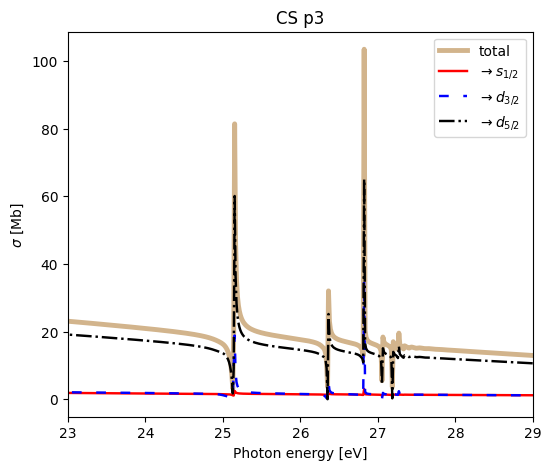

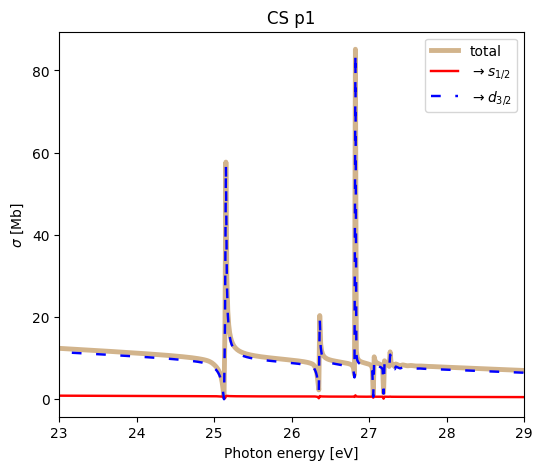

In [6]:
# rel cross section 
en_p3, cs_p3 = cs.get_total_integrated_cross_section_for_hole(kr_1ph, kr_4p3_n, kr_4p3_kappa)
en_p3, cs_p3_s1 = cs.get_partial_integrated_cross_section_1_channel(kr_1ph, kr_4p3_n, kr_4p3_kappa, -1)
en_p3, cs_p3_d3 = cs.get_partial_integrated_cross_section_1_channel(kr_1ph, kr_4p3_n, kr_4p3_kappa, 2)
en_p3, cs_p3_d5 = cs.get_partial_integrated_cross_section_1_channel(kr_1ph, kr_4p3_n, kr_4p3_kappa, -3)

en_p1, cs_p1 = cs.get_total_integrated_cross_section_for_hole(kr_1ph, kr_4p1_n, kr_4p1_kappa)
en_p1, cs_p1_s1 = cs.get_partial_integrated_cross_section_1_channel(kr_1ph, kr_4p1_n, kr_4p1_kappa, -1)
en_p1, cs_p1_d3 = cs.get_partial_integrated_cross_section_1_channel(kr_1ph, kr_4p1_n, kr_4p1_kappa, 2)

en_rel = en_p3 + kr_4p3_hole.binding_energy * g_eV_per_Hartree # restore the photon energy

plt.figure("CS p3", figsize=(6, 5))
plt.plot(en_rel, cs_p3, linewidth=3.5, color="tan", label="total");
plt.plot(en_rel, cs_p3_s1, "-", linewidth=1.75, color="red", label="$\\to s_{1/2}$");
plt.plot(en_rel, cs_p3_d3, linestyle=(20, (4, 6)), linewidth=1.75, color="blue", label="$\\to d_{3/2}$");
plt.plot(en_rel, cs_p3_d5, "-.", linewidth=1.75, color="black", label="$\\to d_{5/2}$");
plt.title("CS p3");
plt.xlim([23, 29]);
plt.xlabel("Photon energy [eV]");
plt.ylabel("$\\sigma$ [Mb]");
plt.legend();

plt.figure("CS p1", figsize=(6, 5))
plt.plot(en_rel, cs_p1, linewidth=3.5, color="tan", label="total");
plt.plot(en_rel, cs_p1_s1, "-", linewidth=1.75, color="red", label="$\\to s_{1/2}$");
plt.plot(en_rel, cs_p1_d3, linestyle=(20, (4, 6)), linewidth=1.75, color="blue", label="$\\to d_{3/2}$");
plt.title("CS p1");
plt.xlim([23, 29]);
plt.xlabel("Photon energy [eV]");
plt.ylabel("$\\sigma$ [Mb]");
plt.legend();

# plt.plot(en, cs_d, "--",  color="red", label="$\\to d$")
# plt.plot(en, cs_s, "--", color="black", label="$\\to s$")
# plt.plot(en, total_cs_norel, color="blue", label="total")
# plt.xlim([23, 29]);
# plt.xlabel("Photon energy [eV]");
# plt.ylabel("$\\sigma$ [Mb]");
# plt.legend();
# plt.title("Nonrel CS");



In [7]:
# # comparison of rel and nonrel cs

# # TODO: check if this is the right way to ADD cs for p3/2 and p1/2
# total_cs_rel = cs_p3 + cs_p1


# plt.plot(en_rel, total_cs_rel, color="blue", label="Rel.")
# plt.plot(en_norel, total_cs_norel, "--", color="red", label="Nonrel.")

# plt.title("CS Rel. vs Nonrel.");
# plt.xlim([25, 25.5]);
# plt.xlabel("Photon energy [eV]");
# plt.ylabel("$\\sigma$ [Mb]");
# plt.legend();


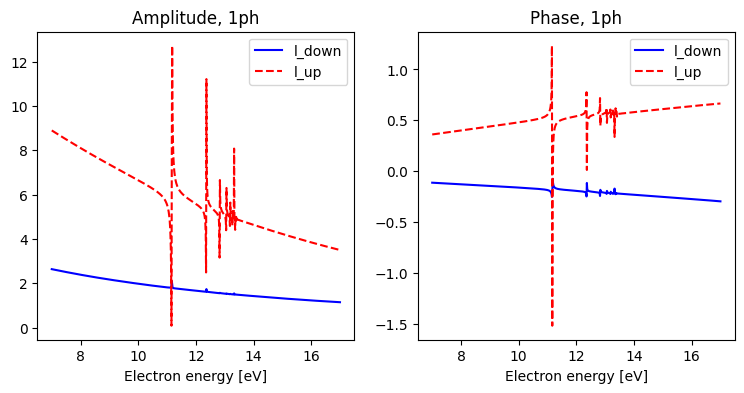

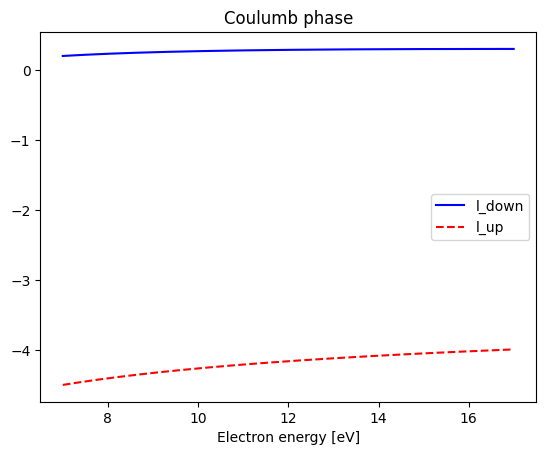

In [8]:
amp_1ph_ldown_file = data_norel + "amplitude_ldown.dat"
amp_1ph_lup_file = data_norel + "amplitude_lup.dat"

phase_1ph_ldown_file = data_norel + "phase_ldown.dat"
phase_1ph_lup_file = data_norel + "phase_lup.dat"


_, amp_1ph_ldown = nonrel_com_util.extract_data_from_file(amp_1ph_ldown_file, 3)
_, amp_1ph_lup = nonrel_com_util.extract_data_from_file(amp_1ph_lup_file, 3)

_, phase_1ph_ldown = nonrel_com_util.extract_data_from_file(phase_1ph_ldown_file, 3)
en_nonrel_hart, phase_1ph_lup = nonrel_com_util.extract_data_from_file(phase_1ph_lup_file, 3)
ekin_nonrel_hart = en_nonrel_hart - nonrel_4p_bind_hart # kinetic energy of the electron in Hartree
ekin_nonrel_eV = ekin_nonrel_hart * g_eV_per_Hartree


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(ekin_nonrel_eV, amp_1ph_ldown, color="blue", label="l_down")
plt.plot(ekin_nonrel_eV, amp_1ph_lup, "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, 1ph")

plt.subplot(1, 2, 2)
plt.plot(ekin_nonrel_eV, np.unwrap(phase_1ph_ldown), color="blue", label="l_down")
plt.plot(ekin_nonrel_eV, np.unwrap(phase_1ph_lup), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, 1ph")


# construct mat. elements
mat_el_1ph_nonrel = np.zeros((len(en_nonrel_hart), 2), dtype=np.complex128)
mat_el_1ph_nonrel[:, 0] = amp_1ph_ldown * np.exp(1j * phase_1ph_ldown)
mat_el_1ph_nonrel[:, 1] = amp_1ph_lup * np.exp(1j * phase_1ph_lup)

# construct Coulomb phase
hole_l = 1
l_up = hole_l + 1
l_down = hole_l - 1
coul_phase_nonrel = np.zeros((len(en_nonrel_hart), 2), dtype=np.float64)
coul_phase_nonrel[:, 0] = nonrel_com_util.coulomb_phase(l_down, ekin_nonrel_hart, Z)
coul_phase_nonrel[:, 1] = nonrel_com_util.coulomb_phase(l_up, ekin_nonrel_hart, Z)

plt.figure()
plt.plot(ekin_nonrel_eV, coul_phase_nonrel[:, 0], color="blue", label="l_down")
plt.plot(ekin_nonrel_eV, coul_phase_nonrel[:, 1], "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Coulumb phase")

# add Coulomb phase to mat. elements
mat_el_1ph_nonrel *= np.exp(1j * coul_phase_nonrel)


Text(0.5, 1.0, 'Phase, upper harm')

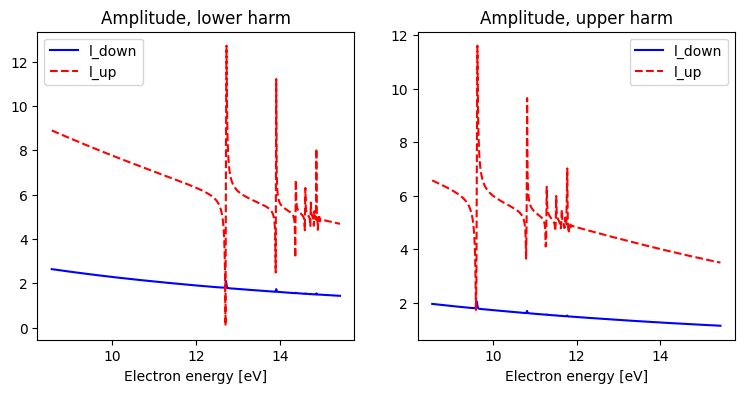

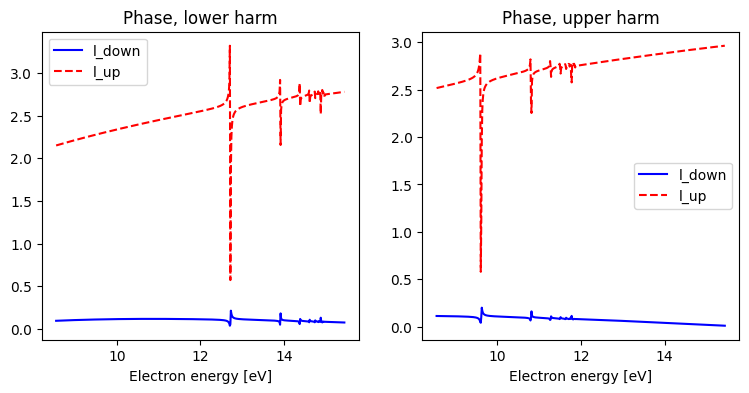

In [9]:
# match non-rel mat. elements

# construct final energies corresponding to the lower and upper harmonic paths
ekin_nonrel_lower_harm_eV = ekin_nonrel_eV + g_omega_IR_eV
ekin_nonrel_upper_harm_eV = ekin_nonrel_eV - g_omega_IR_eV

ekin_mask = ekin_nonrel_lower_harm_eV <= (np.max(ekin_nonrel_eV) - g_omega_IR_eV)
ekin_nonrel_final_eV = ekin_nonrel_lower_harm_eV[ekin_mask]


mat_el_nonrel_lower_harm = np.zeros((len(ekin_nonrel_final_eV), 2), dtype=np.complex128)
mat_el_nonrel_upper_harm = np.zeros((len(ekin_nonrel_final_eV), 2), dtype=np.complex128)

for i in range(2):
    mat_el_nonrel_upper_harm[:, i], mat_el_nonrel_lower_harm[:, i] = glob_util.match_matrix_elements_2sim(
        ekin_nonrel_final_eV,
        ekin_nonrel_upper_harm_eV,
        ekin_nonrel_lower_harm_eV,
        mat_el_1ph_nonrel[:, i],
        mat_el_1ph_nonrel[:, i],
        match_mode="interp_both"
        )


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(ekin_nonrel_final_eV, np.abs(mat_el_nonrel_lower_harm[:, 0]), color="blue", label="l_down")
plt.plot(ekin_nonrel_final_eV, np.abs(mat_el_nonrel_lower_harm[:, 1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, lower harm")

plt.subplot(1, 2, 2)
plt.plot(ekin_nonrel_final_eV, np.abs(mat_el_nonrel_upper_harm[:, 0]), color="blue", label="l_down")
plt.plot(ekin_nonrel_final_eV, np.abs(mat_el_nonrel_upper_harm[:, 1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, upper harm")


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(ekin_nonrel_final_eV,  np.unwrap(np.angle(mat_el_nonrel_lower_harm[:, 0])), color="blue", label="l_down")
plt.plot(ekin_nonrel_final_eV,  np.unwrap(np.angle(mat_el_nonrel_lower_harm[:, 1])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, lower harm")

plt.subplot(1, 2, 2)
plt.plot(ekin_nonrel_final_eV,  np.unwrap(np.angle(mat_el_nonrel_upper_harm[:, 0])), color="blue", label="l_down")
plt.plot(ekin_nonrel_final_eV,  np.unwrap(np.angle(mat_el_nonrel_upper_harm[:, 1])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, upper harm")

In [10]:
from math import radians
from scipy.special import sph_harm_y
from sympy.physics.wigner import wigner_3j

In [11]:
# amplitude = 0 
# fi_rad = 1.5 * np.pi / 3
# theta_rad = np.pi / 3

# l_final = [l_down, l_up] # final angular momenta

# for i in range(len(l_final)):
#     l = l_final[i]
#     l = int(l)
#     for m in np.arange(-l, l+1, 1):
#         m = int(m)
#         print(l, m)
#         # NOTE: do we need the 3j symbol in the prefactor?
#         pre_factor = sph_harm_y(l, m, theta_rad, fi_rad)
#         # pre_factor = sph_harm_y(l, m, theta_rad, fi_rad) * ((-1) ** (l - m)) * float(wigner_3j(l, 1, hole_l, -m, 0, m))
#         amplitude += pre_factor * mat_el_nonrel_lower_harm[0, i]

# print(np.abs(amplitude) ** 2)

In [12]:
# mat_el_nonrel_lower_harm[:, 1] = 0.0 + 0.0 * 1j
# mat_el_nonrel_upper_harm[:, 1] = 0.0 + 0.0 * 1j

# amp_data_4p3 = kr_1ph_4p3_channels.return_amp_data()
# amp_data_4p3[:, 1] = 0.0
# amp_data_4p3[:, 2] = 0.0

# amp_data_4p1 = kr_1ph_4p1_channels.return_amp_data()
# amp_data_4p1[:, 2] = 0.0

In [13]:
l_to_index_1ph = {l_down: 0, l_up: 1} # matches the final l value to the corresponding column index in the mat. elements 

Couple for m: -2
possible l: [2]
Couple for m: -1
possible l: [2]
Couple for m: 0
possible l: [0, 2]
Couple for m: 1
possible l: [2]
Couple for m: 2
possible l: [2]


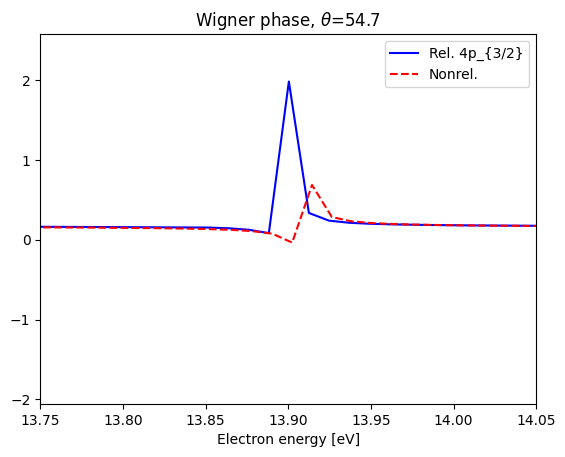

In [14]:
# compute the angular Wigner phase
theta_deg = 54.7
theta_rad = radians(theta_deg)

wigner_intensity_ang_nonrel = np.zeros(len(ekin_nonrel_final_eV), dtype=np.complex128)


m_possible = np.arange(-l_up, l_up+1, 1) # possible m for the ionization; computed using the highest final l, which automaticaly includes the lowest

for m in m_possible:
    m = int(m)
    print(f"Couple for m: {m}")
    l_possible = [] # the list of possible final l giving the m value
    if np.abs(m) <= l_down:
        l_possible.append(l_down)

    l_possible.append(l_up) # always include the highest final l

    print(f"possible l: {l_possible}")

    lower_harm_contr = np.zeros(len(ekin_nonrel_final_eV), dtype=np.complex128)
    upper_harm_contr = np.zeros(len(ekin_nonrel_final_eV), dtype=np.complex128)

    for l in l_possible:
        l_index = l_to_index_1ph[l]
        pre_factor = sph_harm_y(l, m, theta_rad, 0) * ((-1) ** (l - m)) * np.float64(wigner_3j(l, 1, hole_l, -m, 0, m))
        lower_harm_contr += pre_factor * mat_el_nonrel_lower_harm[:, l_index]
        upper_harm_contr += pre_factor * mat_el_nonrel_upper_harm[:, l_index]

    wigner_intensity_ang_nonrel += np.conjugate(lower_harm_contr) * upper_harm_contr

# NOTE: mutiple by 2 to account for spin. Is it the valid way??
wigner_intensity_ang_nonrel *= 2


wigner_phase_ang_nonrel = np.angle(wigner_intensity_ang_nonrel)

# # get the relativistc phase
ekin_rel_final_4p3_eV, wigner_phase_ang_rel_4p3 = wigner.get_wigner_phase(
                                                        kr_1ph, 
                                                        kr_4p3_n, 
                                                        kr_4p3_kappa,
                                                        Z,
                                                        g_omega_IR_hart,
                                                        [theta_deg],
                                                        unwrap=False,
                                                    )
ekin_rel_final_4p1_eV, wigner_phase_ang_rel_4p1 = wigner.get_wigner_phase(
                                                        kr_1ph, 
                                                        kr_4p1_n, 
                                                        kr_4p1_kappa,
                                                        Z,
                                                        g_omega_IR_hart,
                                                        [theta_deg],
                                                        unwrap=False,
                                                    )

plt.figure()
plt.plot(ekin_rel_final_4p3_eV, wigner_phase_ang_rel_4p3[0, :], color="blue", label="Rel. 4p_{3/2}")
# plt.plot(ekin_rel_final_4p1_eV, wigner_phase_ang_rel_4p1[0, :], "-.", color="black", label="Rel. 4p_{1/2}")
plt.plot(ekin_nonrel_final_eV, wigner_phase_ang_nonrel, "--", color="red", label="Nonrel.")
plt.xlabel("Electron energy [eV]")
plt.title(f"Wigner phase, $\\theta$={theta_deg}")
plt.legend()
plt.xlim([13.75, 14.05]);



Couple for m: -2
possible l: [2]
Couple for m: -1
possible l: [2]
Couple for m: 0
possible l: [0, 2]
Couple for m: 1
possible l: [2]
Couple for m: 2
possible l: [2]


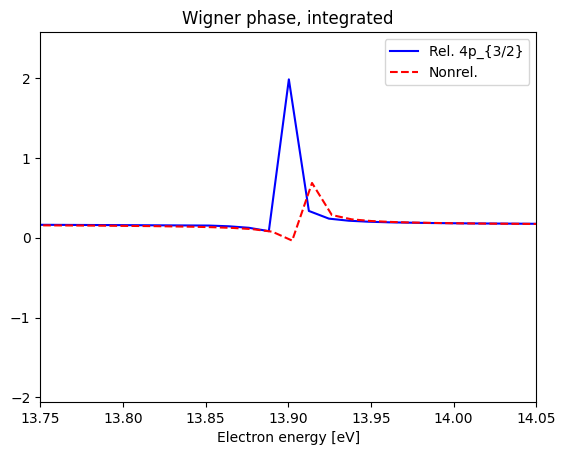

In [15]:
# compute the integrated Wigner phase
wigner_intensity_int_nonrel = np.zeros(len(ekin_nonrel_final_eV), dtype=np.complex128)


m_possible = np.arange(-l_up, l_up+1, 1) # possible m for the ionization; computed using the highest final l, which automaticaly includes the lowest

for m in m_possible:
    m = int(m)
    print(f"Couple for m: {m}")
    l_possible = [] # the list of possible final l giving the m value
    if np.abs(m) <= l_down:
        l_possible.append(l_down)

    l_possible.append(l_up) # always include the highest final l

    print(f"possible l: {l_possible}")

    for l in l_possible:
        l_index = l_to_index_1ph[l]
        w3j = np.float64(wigner_3j(l, 1, hole_l, -m, 0, m))
        wigner_intensity_int_nonrel += (
            w3j ** 2 * np.conjugate(mat_el_nonrel_lower_harm[:, l_index]) * mat_el_nonrel_upper_harm[:, l_index]
        )

# NOTE: mutiple by 2 to account for spin. Is it the valid way??
wigner_intensity_int_nonrel *= 2


wigner_phase_int_nonrel = np.angle(wigner_intensity_int_nonrel)

# get the relativistc phase
ekin_rel_final_4p3_eV, wigner_phase_int_rel_4p3 = wigner.get_integrated_wigner_phase(
                                                        kr_1ph, 
                                                        kr_4p3_n, 
                                                        kr_4p3_kappa,
                                                        Z,
                                                        g_omega_IR_hart,
                                                        unwrap=False,
                                                    )
ekin_rel_final_4p1_eV, wigner_phase_int_rel_4p1 = wigner.get_integrated_wigner_phase(
                                                        kr_1ph, 
                                                        kr_4p1_n, 
                                                        kr_4p1_kappa,
                                                        Z,
                                                        g_omega_IR_hart,
                                                        unwrap=False,
                                                    )

plt.figure()
plt.plot(ekin_rel_final_4p3_eV, wigner_phase_int_rel_4p3, color="blue", label="Rel. 4p_{3/2}")
# plt.plot(ekin_rel_final_4p1_eV, wigner_phase_int_rel_4p1, "-.", color="black", label="Rel. 4p_{1/2}")
plt.plot(ekin_nonrel_final_eV, wigner_phase_int_nonrel, "--", color="red", label="Nonrel.")
plt.xlabel("Electron energy [eV]")
plt.title("Wigner phase, integrated")
plt.legend()
plt.xlim([13.75, 14.05]);




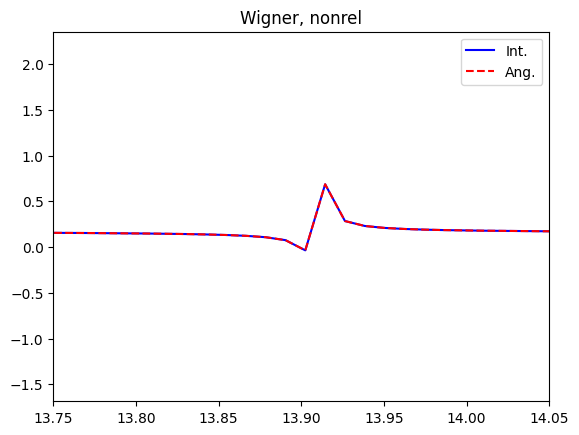

In [16]:
plt.plot(ekin_nonrel_final_eV, wigner_phase_int_nonrel, color="blue", label="Int.")
plt.plot(ekin_nonrel_final_eV, wigner_phase_ang_nonrel, "--", color="red", label="Ang.")
plt.title("Wigner, nonrel")
plt.legend();
plt.xlim([13.75, 14.05]);

In [17]:
l_to_index_2ph = {1: 1, 3: 2}

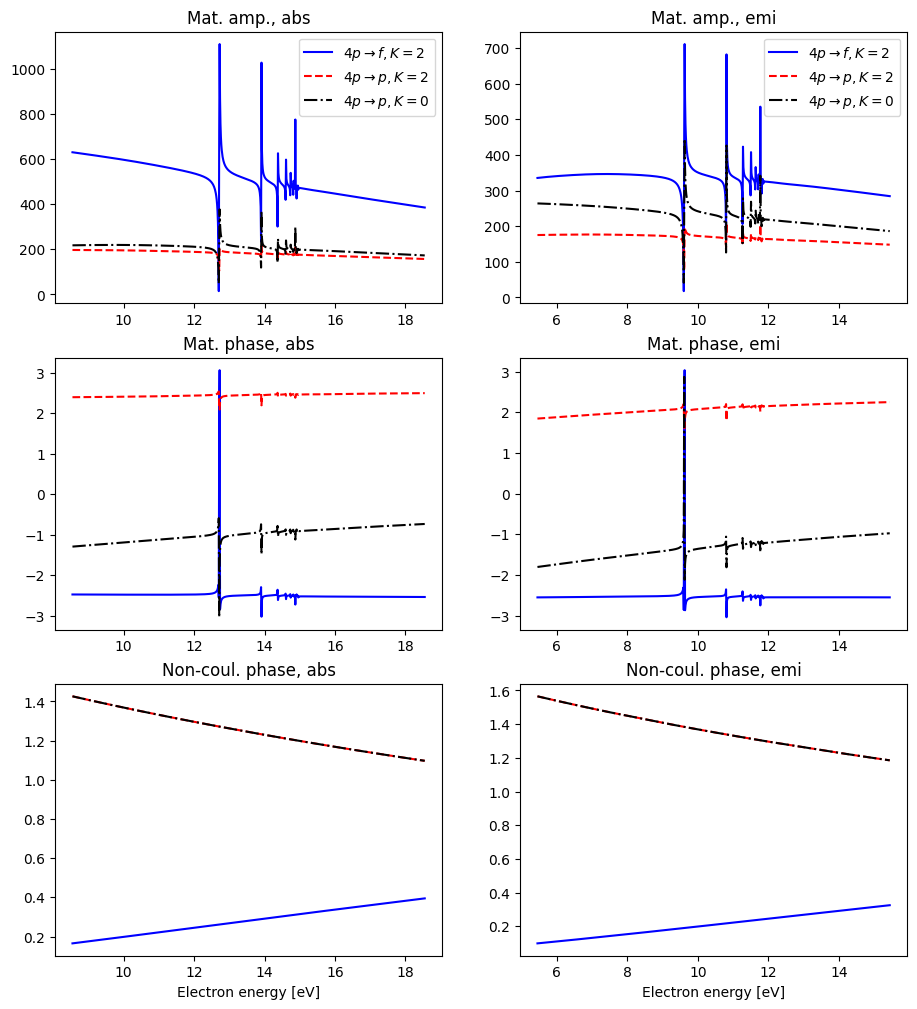

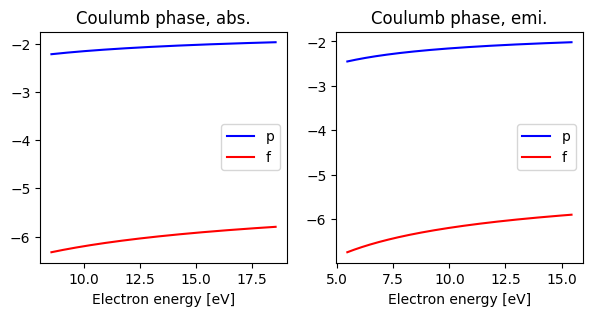

In [18]:
abs_4pfD_file = data_norel + "abs_4pfD_0.dat"
emi_4pfD_file = data_norel + "emi_4pfD_0.dat"

abs_4ppD_file = data_norel + "abs_4ppD_0.dat"
emi_4ppD_file = data_norel + "emi_4ppD_0.dat"

abs_4ppS_file = data_norel + "abs_4ppS_0.dat"
emi_4ppS_file = data_norel + "emi_4ppS_0.dat"

_, mat_el_abs_4pfD, non_coul_abs_4pfD = nonrel_utils_2ph.extract_mat_el_from_verbose_file(abs_4pfD_file, 3)
_, mat_el_emi_4pfD, non_coul_emi_4pfD = nonrel_utils_2ph.extract_mat_el_from_verbose_file(emi_4pfD_file, 3)

_, mat_el_abs_4ppD, non_coul_abs_4ppD = nonrel_utils_2ph.extract_mat_el_from_verbose_file(abs_4ppD_file, 3)
_, mat_el_emi_4ppD, non_coul_emi_4ppD = nonrel_utils_2ph.extract_mat_el_from_verbose_file(emi_4ppD_file, 3)

en_abs_nonrel_eV, mat_el_abs_4ppS, non_coul_abs_4ppS = nonrel_utils_2ph.extract_mat_el_from_verbose_file(abs_4ppS_file, 3)
en_emi_nonrel_eV, mat_el_emi_4ppS, non_coul_emi_4ppS = nonrel_utils_2ph.extract_mat_el_from_verbose_file(emi_4ppS_file, 3)

ekin_abs_nonrel_eV = en_abs_nonrel_eV - nonrel_4p_bind_eV
ekin_emi_nonrel_eV = en_emi_nonrel_eV - nonrel_4p_bind_eV

ekin_abs_nonrel_hart = ekin_abs_nonrel_eV / g_eV_per_Hartree
ekin_emi_nonrel_hart = ekin_emi_nonrel_eV / g_eV_per_Hartree


plt.figure(figsize=(11, 12))
plt.subplot(3, 2, 1)
plt.plot(ekin_abs_nonrel_eV, np.abs(mat_el_abs_4pfD), color="blue", label="$4p \\to f, K=2$")
plt.plot(ekin_abs_nonrel_eV, np.abs(mat_el_abs_4ppD), "--", color="red", label="$4p \\to p, K=2$")
plt.plot(ekin_abs_nonrel_eV, np.abs(mat_el_abs_4ppS), "-.", color="black", label="$4p \\to p, K=0$")
plt.legend()
plt.title("Mat. amp., abs")

plt.subplot(3, 2, 2)
plt.plot(ekin_emi_nonrel_eV, np.abs(mat_el_emi_4pfD), color="blue", label="$4p \\to f, K=2$")
plt.plot(ekin_emi_nonrel_eV, np.abs(mat_el_emi_4ppD), "--", color="red", label="$4p \\to p, K=2$")
plt.plot(ekin_emi_nonrel_eV, np.abs(mat_el_emi_4ppS), "-.", color="black", label="$4p \\to p, K=0$")
plt.legend()
plt.title("Mat. amp., emi")

plt.subplot(3, 2, 3)
plt.plot(ekin_abs_nonrel_eV, np.angle(mat_el_abs_4pfD), color="blue", label="$4p \\to f, K=2$")
plt.plot(ekin_abs_nonrel_eV, np.angle(mat_el_abs_4ppD), "--", color="red", label="$4p \\to p, K=2$")
plt.plot(ekin_abs_nonrel_eV, np.angle(mat_el_abs_4ppS), "-.", color="black", label="$4p \\to p, K=0$")
plt.title("Mat. phase, abs")

plt.subplot(3, 2, 4)
plt.plot(ekin_emi_nonrel_eV, np.angle(mat_el_emi_4pfD), color="blue", label="$4p \\to f, K=2$")
plt.plot(ekin_emi_nonrel_eV, np.angle(mat_el_emi_4ppD), "--", color="red", label="$4p \\to p, K=2$")
plt.plot(ekin_emi_nonrel_eV, np.angle(mat_el_emi_4ppS), "-.", color="black", label="$4p \\to p, K=0$")
plt.title("Mat. phase, emi")

plt.subplot(3, 2, 5)
plt.plot(ekin_abs_nonrel_eV, non_coul_abs_4pfD, color="blue", label="$4p \\to f, K=2$")
plt.plot(ekin_abs_nonrel_eV, non_coul_abs_4ppD, "--", color="red", label="$4p \\to p, K=2$")
plt.plot(ekin_abs_nonrel_eV, non_coul_abs_4ppS, "-.", color="black", label="$4p \\to p, K=0$")
plt.xlabel("Electron energy [eV]")
plt.title("Non-coul. phase, abs")

plt.subplot(3, 2, 6)
plt.plot(ekin_emi_nonrel_eV, non_coul_emi_4pfD, color="blue", label="$4p \\to f, K=2$")
plt.plot(ekin_emi_nonrel_eV, non_coul_emi_4ppD, "--", color="red", label="$4p \\to p, K=2$")
plt.plot(ekin_emi_nonrel_eV, non_coul_emi_4ppS, "-.", color="black", label="$4p \\to p, K=0$")
plt.xlabel("Electron energy [eV]")
plt.title("Non-coul. phase, emi")

# construct mat. elements
mat_el_2ph_abs_nonrel = np.zeros((3, 3, len(en_abs_nonrel_eV)), dtype=np.complex128)
mat_el_2ph_emi_nonrel = np.zeros((3, 3, len(en_emi_nonrel_eV)), dtype=np.complex128)

mat_el_2ph_abs_nonrel[1, 0, :] = mat_el_abs_4ppS * np.exp(1j * non_coul_abs_4ppS)
mat_el_2ph_emi_nonrel[1, 0, :] = mat_el_emi_4ppS * np.exp(1j * non_coul_emi_4ppS)

mat_el_2ph_abs_nonrel[1, 2, :] = mat_el_abs_4ppD * np.exp(1j * non_coul_abs_4ppD)
mat_el_2ph_emi_nonrel[1, 2, :] = mat_el_emi_4ppD * np.exp(1j * non_coul_emi_4ppD)


mat_el_2ph_abs_nonrel[2, 2, :] = mat_el_abs_4pfD * np.exp(1j * non_coul_abs_4pfD)
mat_el_2ph_emi_nonrel[2, 2, :] = mat_el_emi_4pfD * np.exp(1j * non_coul_emi_4pfD)

# construct Coulomb phase
coul_phase_p_abs = nonrel_com_util.coulomb_phase(1, ekin_abs_nonrel_hart, Z)
coul_phase_p_emi = nonrel_com_util.coulomb_phase(1, ekin_emi_nonrel_hart, Z)
coul_phase_f_abs = nonrel_com_util.coulomb_phase(3, ekin_abs_nonrel_hart, Z)
coul_phase_f_emi = nonrel_com_util.coulomb_phase(3, ekin_emi_nonrel_hart, Z)

plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.plot(ekin_abs_nonrel_eV, coul_phase_p_abs, color="blue", label="p")
plt.plot(ekin_abs_nonrel_eV, coul_phase_f_abs, color="red", label="f")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Coulumb phase, abs.")

plt.subplot(1, 2, 2)
plt.plot(ekin_emi_nonrel_eV, coul_phase_p_emi, color="blue", label="p")
plt.plot(ekin_emi_nonrel_eV, coul_phase_f_emi, color="red", label="f")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Coulumb phase, emi.")

# add Coulomb phase to mat. elements
# NOTE: could create a matching array with the Coulomb phase
mat_el_2ph_abs_nonrel[1, 0, :] *= np.exp(1j * coul_phase_p_abs)
mat_el_2ph_emi_nonrel[1, 0, :] *= np.exp(1j * coul_phase_p_emi)

mat_el_2ph_abs_nonrel[1, 2, :] *= np.exp(1j * coul_phase_p_abs)
mat_el_2ph_emi_nonrel[1, 2, :] *= np.exp(1j * coul_phase_p_emi)

mat_el_2ph_abs_nonrel[2, 2, :] *= np.exp(1j * coul_phase_f_abs)
mat_el_2ph_emi_nonrel[2, 2, :] *= np.exp(1j * coul_phase_f_emi)

Text(0.5, 1.0, 'Phase, emi')

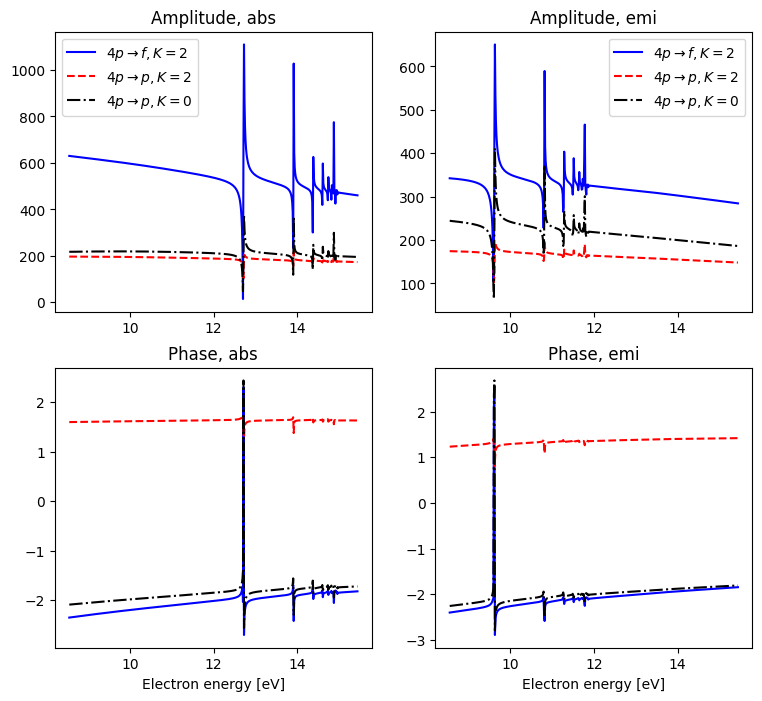

In [19]:
# match non-rel mat. elements

# match through absorption arm. Works well for 1 sim cause in this case no need to interploate abs mat elements
ekin_mask = ekin_abs_nonrel_eV <= (np.max(ekin_abs_nonrel_eV) - 2 * g_omega_IR_eV)
ekin_2ph_nonrel_final_eV = ekin_abs_nonrel_eV[ekin_mask]


mat_el_2ph_abs_nonrel_matched = np.zeros((3, 3, len(ekin_2ph_nonrel_final_eV)), dtype=np.complex128)
mat_el_2ph_emi_nonrel_matched = np.zeros((3, 3, len(ekin_2ph_nonrel_final_eV)), dtype=np.complex128)

for i in range(3):
    for K in range(3):
        mat_el_2ph_abs_nonrel_matched[i, K, :] = mat_el_2ph_abs_nonrel[i, K, ekin_mask]
        mat_el_2ph_emi_nonrel_matched[i, K, :] = np.interp(
                                                    ekin_2ph_nonrel_final_eV,
                                                    ekin_emi_nonrel_eV,              
                                                    mat_el_2ph_emi_nonrel[i, K, :]
                                                )


plt.figure(figsize=(9, 8))
plt.subplot(2, 2, 1)
plt.plot(ekin_2ph_nonrel_final_eV, np.abs(mat_el_2ph_abs_nonrel_matched[2, 2, :]), color="blue", label="$4p \\to f, K=2$")
plt.plot(ekin_2ph_nonrel_final_eV, np.abs(mat_el_2ph_abs_nonrel_matched[1, 2, :]), "--", color="red", label="$4p \\to p, K=2$")
plt.plot(ekin_2ph_nonrel_final_eV, np.abs(mat_el_2ph_abs_nonrel_matched[1, 0, :]), "-.", color="black", label="$4p \\to p, K=0$")
plt.legend()
plt.title("Amplitude, abs")

plt.subplot(2, 2, 2)
plt.plot(ekin_2ph_nonrel_final_eV, np.abs(mat_el_2ph_emi_nonrel_matched[2, 2, :]), color="blue", label="$4p \\to f, K=2$")
plt.plot(ekin_2ph_nonrel_final_eV, np.abs(mat_el_2ph_emi_nonrel_matched[1, 2, :]), "--", color="red", label="$4p \\to p, K=2$")
plt.plot(ekin_2ph_nonrel_final_eV, np.abs(mat_el_2ph_emi_nonrel_matched[1, 0, :]), "-.", color="black", label="$4p \\to p, K=0$")
plt.legend()
plt.title("Amplitude, emi")

plt.subplot(2, 2, 3)
plt.plot(ekin_2ph_nonrel_final_eV, np.angle(mat_el_2ph_abs_nonrel_matched[2, 2, :]), color="blue", label="$4p \\to f, K=2$")
plt.plot(ekin_2ph_nonrel_final_eV, np.angle(mat_el_2ph_abs_nonrel_matched[1, 2, :]), "--", color="red", label="$4p \\to p, K=2$")
plt.plot(ekin_2ph_nonrel_final_eV, np.angle(mat_el_2ph_abs_nonrel_matched[1, 0, :]), "-.", color="black", label="$4p \\to p, K=0$")
plt.xlabel("Electron energy [eV]")
plt.title("Phase, abs")

plt.subplot(2, 2, 4)
plt.plot(ekin_2ph_nonrel_final_eV, np.angle(mat_el_2ph_emi_nonrel_matched[2, 2, :]), color="blue", label="$4p \\to f, K=2$")
plt.plot(ekin_2ph_nonrel_final_eV, np.angle(mat_el_2ph_emi_nonrel_matched[1, 2, :]), "--", color="red", label="$4p \\to p, K=2$")
plt.plot(ekin_2ph_nonrel_final_eV, np.angle(mat_el_2ph_emi_nonrel_matched[1, 0, :]), "-.", color="black", label="$4p \\to p, K=0$")
plt.xlabel("Electron energy [eV]")
plt.title("Phase, emi")

In [20]:
l_f = 3
l_p = 1

l_final_2ph = [l_p, l_f]

Couple for m: -3
possible l: [3]
Couple for m: -2
possible l: [3]
Couple for m: -1
possible l: [1, 3]
Couple for m: 0
possible l: [1, 3]
Couple for m: 1
possible l: [1, 3]
Couple for m: 2
possible l: [3]
Couple for m: 3
possible l: [3]


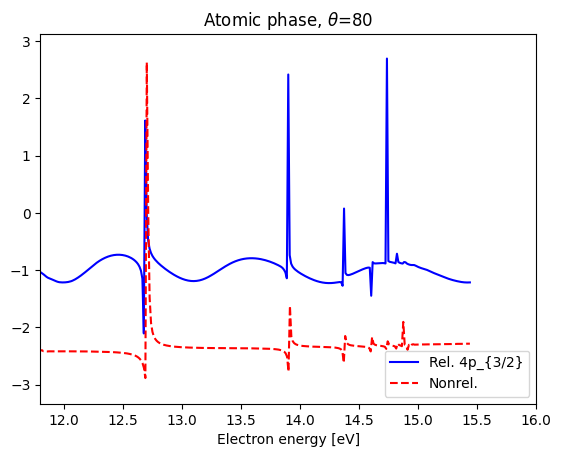

In [21]:
# compute the angular atomic phase
theta_deg = 80
theta_rad = radians(theta_deg)

atomic_intensity_ang_nonrel = np.zeros(len(ekin_2ph_nonrel_final_eV), dtype=np.complex128)


m_possible = np.arange(-l_f, l_f+1, 1) # possible m for the ionization; computed using the highest final l, which automaticaly includes lower l

for m in m_possible:
    m = int(m)
    print(f"Couple for m: {m}")
    l_possible = [] # the list of possible final l giving the m value
    if np.abs(m) <= l_p:
        l_possible.append(l_p)

    l_possible.append(l_f) # always include the highest final l

    print(f"possible l: {l_possible}")

    abs_contr = np.zeros(len(ekin_2ph_nonrel_final_eV), dtype=np.complex128)
    emi_contr = np.zeros(len(ekin_2ph_nonrel_final_eV), dtype=np.complex128)

    for l in l_possible:
        l_index = l_to_index_2ph[l]
        for K in range(3):
            pre_factor = sph_harm_y(l, m, theta_rad, 0) * ((-1) ** (l - m)) * np.float64(wigner_3j(l, K, hole_l, -m, 0, m))
            abs_contr += pre_factor * mat_el_2ph_abs_nonrel_matched[l_index, K, :]
            emi_contr += pre_factor * mat_el_2ph_emi_nonrel_matched[l_index, K, :]

    atomic_intensity_ang_nonrel += np.conjugate(abs_contr) * emi_contr

# NOTE: mutiple by 2 to account for spin. Is it the valid way??
atomic_intensity_ang_nonrel *= 2


atomic_phase_ang_nonrel = np.angle(atomic_intensity_ang_nonrel)

# # get the relativistc phase
ekin_rel_final_4p3_eV, atomic_phase_ang_rel_4p3 = atomic.get_atomic_phase(
                                                        kr_2ph, 
                                                        kr_4p3_n, 
                                                        kr_4p3_kappa,
                                                        Z,
                                                        [theta_deg],
                                                        unwrap=False,
                                                    )
ekin_rel_final_4p1_eV, atomic_phase_ang_rel_4p1 = atomic.get_atomic_phase(
                                                        kr_2ph, 
                                                        kr_4p1_n, 
                                                        kr_4p1_kappa,
                                                        Z,
                                                        [theta_deg],
                                                        unwrap=False,
                                                    )

plt.figure()
plt.plot(ekin_rel_final_4p3_eV, atomic_phase_ang_rel_4p3[0, :], color="blue", label="Rel. 4p_{3/2}")
# plt.plot(ekin_rel_final_4p1_eV, wigner_phase_ang_rel_4p1[0, :], "-.", color="black", label="Rel. 4p_{1/2}")
plt.plot(ekin_2ph_nonrel_final_eV, atomic_phase_ang_nonrel, "--", color="red", label="Nonrel.")
plt.xlabel("Electron energy [eV]")
plt.title(f"Atomic phase, $\\theta$={theta_deg}")
plt.legend()
plt.xlim([11.8, 16]);



Couple for m: -3
possible l: [3]
Couple for m: -2
possible l: [3]
Couple for m: -1
possible l: [1, 3]
Couple for m: 0
possible l: [1, 3]
Couple for m: 1
possible l: [1, 3]
Couple for m: 2
possible l: [3]
Couple for m: 3
possible l: [3]


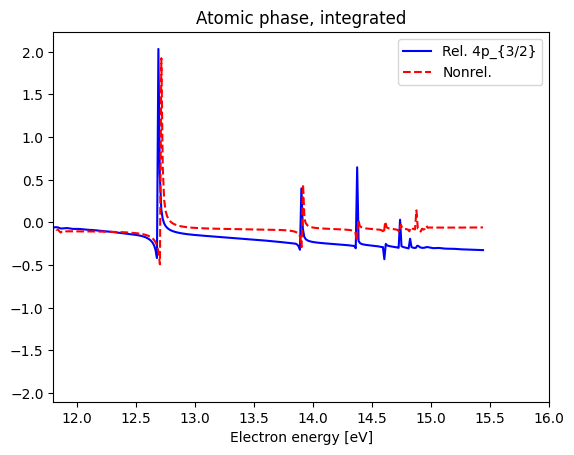

In [22]:
# compute the integrated atomic phase
atomic_intensity_int_nonrel = np.zeros(len(ekin_2ph_nonrel_final_eV), dtype=np.complex128)


m_possible = np.arange(-l_f, l_f+1, 1) # possible m for the ionization; computed using the highest final l, which automaticaly includes lower l

for m in m_possible:
    m = int(m)
    print(f"Couple for m: {m}")
    l_possible = [] # the list of possible final l giving the m value
    if np.abs(m) <= l_p:
        l_possible.append(l_p)

    l_possible.append(l_f) # always include the highest final l

    print(f"possible l: {l_possible}")

    abs_contr = np.zeros(len(ekin_2ph_nonrel_final_eV), dtype=np.complex128)
    emi_contr = np.zeros(len(ekin_2ph_nonrel_final_eV), dtype=np.complex128)

    for l in l_possible:
        l_index = l_to_index_2ph[l]
        for K in range(3):
            w3j = np.float64(wigner_3j(l, K, hole_l, -m, 0, m))
            abs_contr += w3j * mat_el_2ph_abs_nonrel_matched[l_index, K, :]
            emi_contr += w3j * mat_el_2ph_emi_nonrel_matched[l_index, K, :]

    atomic_intensity_int_nonrel += np.conjugate(abs_contr) * emi_contr

# NOTE: mutiple by 2 to account for spin. Is it the valid way??
atomic_intensity_int_nonrel *= 2


atomic_phase_int_nonrel = np.unwrap(np.angle(atomic_intensity_int_nonrel))

# # get the relativistc phase
ekin_rel_final_4p3_eV, atomic_phase_int_rel_4p3 = atomic.get_integrated_atomic_phase(
                                                        kr_2ph, 
                                                        kr_4p3_n, 
                                                        kr_4p3_kappa,
                                                        Z,
                                                        unwrap=True,
                                                    )
ekin_rel_final_4p1_eV, atomic_phase_int_rel_4p1 = atomic.get_integrated_atomic_phase(
                                                        kr_2ph, 
                                                        kr_4p1_n, 
                                                        kr_4p1_kappa,
                                                        Z,
                                                        unwrap=False,
                                                    )

plt.figure()
plt.plot(ekin_rel_final_4p3_eV, atomic_phase_int_rel_4p3, color="blue", label="Rel. 4p_{3/2}")
# plt.plot(ekin_rel_final_4p1_eV, wigner_phase_ang_rel_4p1, "-.", color="black", label="Rel. 4p_{1/2}")
plt.plot(ekin_2ph_nonrel_final_eV, atomic_phase_int_nonrel, "--", color="red", label="Nonrel.")
plt.xlabel("Electron energy [eV]")
plt.title(f"Atomic phase, integrated")
plt.legend()
plt.xlim([11.8, 16]);



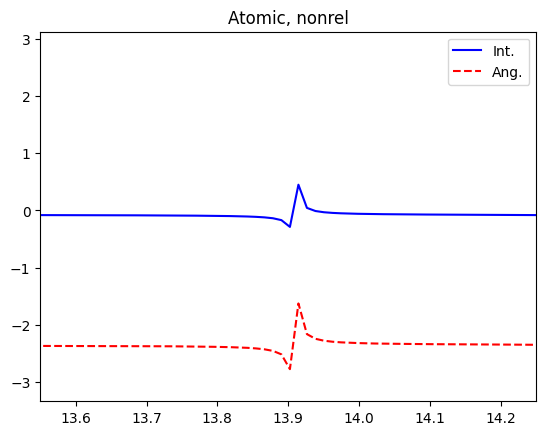

In [23]:
plt.plot(ekin_2ph_nonrel_final_eV, atomic_phase_int_nonrel, color="blue", label="Int.")
plt.plot(ekin_2ph_nonrel_final_eV, atomic_phase_ang_nonrel, "--", color="red", label="Ang.")
plt.title("Atomic, nonrel")
plt.legend();
plt.xlim([13.55, 14.25]);